<a href="https://colab.research.google.com/github/srinivasannandagopal94-pixel/Global-Tourism-and-Booking-Behavior-A-Comprehensive-Data-Analysis/blob/main/Global_Tourism_and_Booking_Behavior_A_Comprehensive_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Global Tourism and Booking Behavior: A Comprehensive Data Analysis**

# **Objective**

1. To clean, transform, and preprocess the raw data by resolving missing records and correcting corrupted placeholder symbols across the dataset to ensure a high-quality foundation for analytical modeling.

2. To identify meaningful patterns and behavioral trends across diverse customer demographics and uncover the primary factors driving why a significant portion of planned trips ultimately get canceled.

3. To create clear, impactful visualizations that illustrate how different booking characteristics, pricing structures, and itinerary choices directly impact final customer satisfaction ratings.

4. To provide actionable business recommendations derived from the data to help minimize cancellation rates, optimize service packages for target markets, and maximize completed trips.

# **Outcome**

The final evidence-based findings provide actionable recommendations, empowering the business to optimize its service offerings, target the right market segments, and minimize revenue loss from cancellations.

# **Domain**
**Tourism**

#**Dataset Information**

**Source:** Portal link: **https://www.untourism.int/tourism-statistics/tourism-statistics-database**</font></u>



**Dataset Column/features Description:**

* **Booking_ID** – Unique identification number for each holiday booking.

* **Country** – The nationality or origin country of the traveler.

* **Age** – The age of the customer.

* **Gender** – The gender identity of the traveler.

* **Travel_Type** – The purpose or category of the trip (e.g., Leisure, Business, Group).

* **Ticket_Price** – The total cost of the travel ticket.

* **Stay_Duration** – The number of days the customer spent on the trip.

* **Hotel_Rating** – The star classification or quality rating of the accommodation.

* **Transport_Mode** – The primary vehicle used for travel (e.g., Flight, Train, Car).

* **Insurance** – Indicates whether the traveler purchased travel insurance for the trip.

* **Meal_Plan** – The type of catering package selected by the customer (e.g., Standard, Buffet).

* **Review_Score** – The satisfaction rating given by the customer after their experience.

* **Baggage_KG** – The total weight allowance of luggage carried by the traveler.

* **Status** – The final state of the booking, indicating whether the trip was completed or canceled.

# **Inital EDA**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("https://github.com/srinivasannandagopal94-pixel/Global-Tourism-and-Booking-Behavior-A-Comprehensive-Data-Analysis/raw/refs/heads/main/Tourism_Project_Raw_Data.csv")
df.head()

,Booking_ID,Country,Age,Gender,Travel_Type,Ticket_Price,Stay_Duration,Hotel_Rating,Transport_Mode,Insurance,Meal_Plan,Review_Score,Baggage_KG,Status
0,BK-5000,Brazil,26,1,Leisure,928.0,2.0,4,Car,1,NaN,4.0,27,Confirmed
1,BK-5001,Japan,29,1,Group,2243.0,5.0,5,Train,0,Buffet,9.0,37,Canceled
2,BK-5002,UAE,70,0,Business,4397.0,13.0,1,Flight,1,NaN,5.0,37,Confirmed
3,BK-5003,Brazil,18,0,Business,3696.0,14.0,3,Train,1,Standard,8.0,38,Confirmed
4,BK-5004,India,75,0,Business,978.0,5.0,4,Car,0,Buffet,9.0,25,Confirmed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Booking_ID      630 non-null    object 
 1   Country         630 non-null    object 
 2   Age             630 non-null    object 
 3   Gender          630 non-null    int64  
 4   Travel_Type     630 non-null    object 
 5   Ticket_Price    620 non-null    float64
 6   Stay_Duration   620 non-null    float64
 7   Hotel_Rating    630 non-null    object 
 8   Transport_Mode  630 non-null    object 
 9   Insurance       630 non-null    int64  
 10  Meal_Plan       408 non-null    object 
 11  Review_Score    615 non-null    float64
 12  Baggage_KG      630 non-null    int64  
 13  Status          630 non-null    object 
dtypes: float64(3), int64(3), object(8)
memory usage: 69.0+ KB


In [ ]:
df.describe()

,Gender,Ticket_Price,Stay_Duration,Insurance,Review_Score,Baggage_KG
count,630.000000,620.000000,620.000000,630.000000,615.000000,630.000000
mean,0.488889,2353.077419,7.477419,0.479365,5.586992,25.025397
std,0.500274,1271.743951,3.945649,0.499971,2.831045,8.408073
min,0.000000,201.000000,1.000000,0.000000,1.000000,10.000000
25%,0.000000,1203.000000,4.000000,0.000000,3.000000,18.000000
50%,0.000000,2379.500000,7.000000,0.000000,6.000000,25.000000
75%,1.000000,3434.750000,11.000000,1.000000,8.000000,32.000000
max,1.000000,4493.000000,14.000000,1.000000,10.000000,39.000000


In [ ]:
df.shape

(630, 14)

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
Country,0
Age,0
Gender,0
Travel_Type,0
Ticket_Price,10
Stay_Duration,10
Hotel_Rating,0
Transport_Mode,0
Insurance,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Fixing Age and Hotel_Rating by converting them to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Hotel_Rating'] = pd.to_numeric(df['Hotel_Rating'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
Country,0
Age,15
Gender,0
Travel_Type,0
Ticket_Price,10
Stay_Duration,10
Hotel_Rating,15
Transport_Mode,0
Insurance,0


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# filling missing values in 'Meal_Plan' column with mode.
df['Meal_Plan'].fillna(df['Meal_Plan'].mode()[0],inplace=True)

In [ ]:
# filling missing values in the following columns with their respective mean values.
df['Ticket_Price'].fillna(df['Ticket_Price'].mean(),inplace=True)
df['Stay_Duration'].fillna(df['Stay_Duration'].mean(),inplace=True)
df['Review_Score'].fillna(df['Review_Score'].mean(),inplace=True)
df['Hotel_Rating'].fillna(df['Hotel_Rating'].mean(),inplace=True)

# filling missing values in the Age column with its median value.
df['Age'].fillna(df['Age'].median(),inplace=True)

df.isnull().sum()

,0
Booking_ID,0
Country,0
Age,0
Gender,0
Travel_Type,0
Ticket_Price,0
Stay_Duration,0
Hotel_Rating,0
Transport_Mode,0
Insurance,0


In [ ]:
# changing values in 'Gender' column to 'Male' and 'Female', instead of 1 and 0.
gender_name = {1: 'Male', 0: 'Female'}
df['Gender'] = df['Gender'].map(gender_name)

In [ ]:
# checking if the 'Gender' column is filled correctly.
print(df['Gender'].unique())

['Male' 'Female']


In [ ]:
# changing values in 'Insurance' column to 'Yes' and 'No', instead of 1 and 0.
insurance_opted = {1: 'Yes', 0: 'No'}
df['Insurance'] = df['Insurance'].map(insurance_opted)

In [ ]:
# checking if the 'Insurance' column is filled correctly.
print(df['Insurance'].unique())

['Yes' 'No']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Booking_ID      630 non-null    object 
 1   Country         630 non-null    object 
 2   Age             630 non-null    float64
 3   Gender          630 non-null    object 
 4   Travel_Type     630 non-null    object 
 5   Ticket_Price    630 non-null    float64
 6   Stay_Duration   630 non-null    float64
 7   Hotel_Rating    630 non-null    float64
 8   Transport_Mode  630 non-null    object 
 9   Insurance       630 non-null    object 
 10  Meal_Plan       630 non-null    object 
 11  Review_Score    630 non-null    float64
 12  Baggage_KG      630 non-null    int64  
 13  Status          630 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 69.0+ KB


In [ ]:
# converting the following datatypes to integer from float.
df['Age'] = df['Age'].astype('int64')
df['Hotel_Rating'] = df['Hotel_Rating'].astype('int64')
df['Review_Score'] = df['Review_Score'].astype('int64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Booking_ID      630 non-null    object 
 1   Country         630 non-null    object 
 2   Age             630 non-null    int64  
 3   Gender          630 non-null    object 
 4   Travel_Type     630 non-null    object 
 5   Ticket_Price    630 non-null    float64
 6   Stay_Duration   630 non-null    float64
 7   Hotel_Rating    630 non-null    int64  
 8   Transport_Mode  630 non-null    object 
 9   Insurance       630 non-null    object 
 10  Meal_Plan       630 non-null    object 
 11  Review_Score    630 non-null    int64  
 12  Baggage_KG      630 non-null    int64  
 13  Status          630 non-null    object 
dtypes: float64(2), int64(4), object(8)
memory usage: 69.0+ KB


In [ ]:
# checking for outliers
df.describe()

,Age,Ticket_Price,Stay_Duration,Hotel_Rating,Review_Score,Baggage_KG
count,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000
mean,48.788889,2353.077419,7.477419,3.063492,5.573016,25.025397
std,17.842222,1261.594196,3.914159,1.425110,2.798518,8.408073
min,18.000000,201.000000,1.000000,1.000000,1.000000,10.000000
25%,34.000000,1212.500000,4.000000,2.000000,3.000000,18.000000
50%,48.000000,2353.077419,7.477419,3.000000,6.000000,25.000000
75%,65.000000,3428.000000,11.000000,4.000000,8.000000,32.000000
max,79.000000,4493.000000,14.000000,5.000000,10.000000,39.000000


In [ ]:
num_col=df.select_dtypes(include="number").columns
num_col

Index(['Age', 'Ticket_Price', 'Stay_Duration', 'Hotel_Rating', 'Review_Score',
       'Baggage_KG'],
      dtype='object')

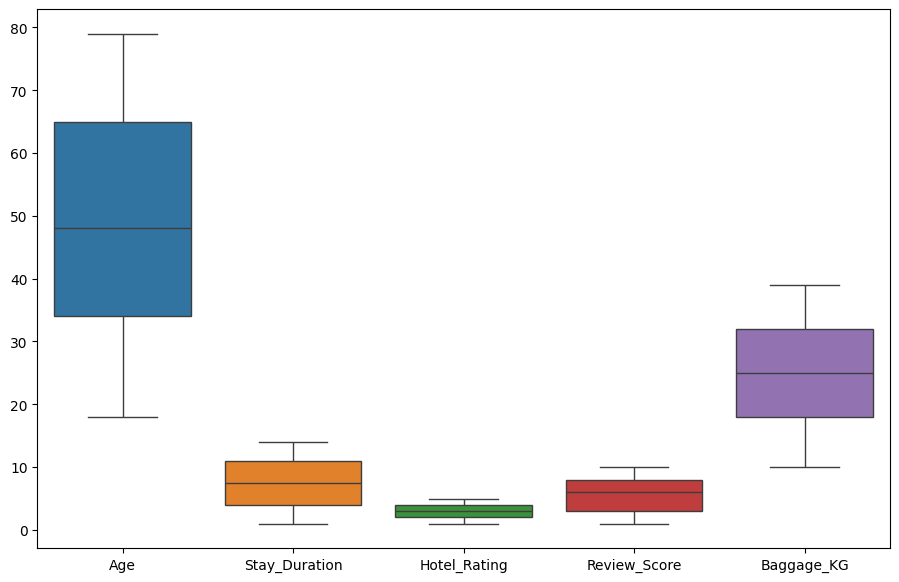

In [ ]:
plt.figure(figsize=(11,7))
sns.boxplot(data=df[['Age', 'Stay_Duration', 'Hotel_Rating', 'Review_Score',
       'Baggage_KG']])
plt.show()

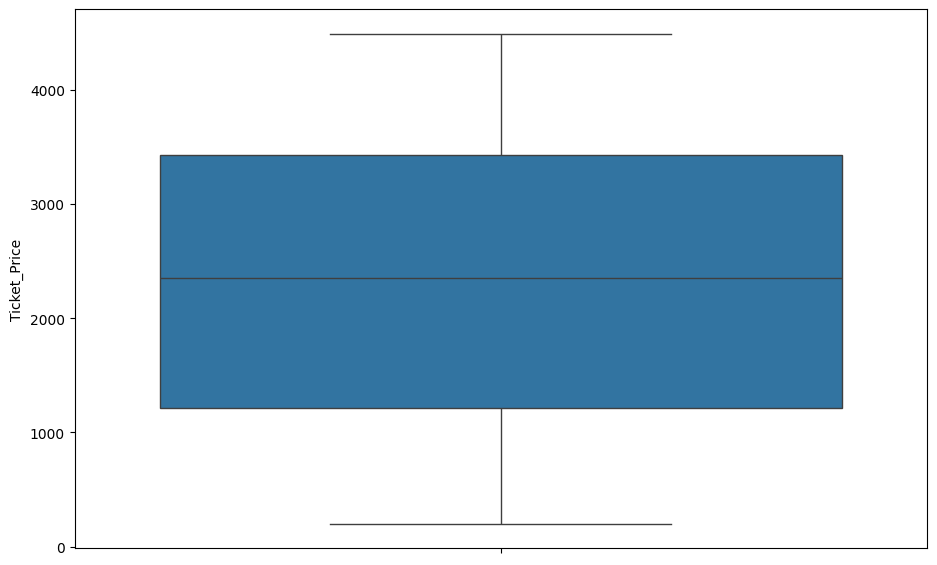

In [ ]:
plt.figure(figsize=(11,7))
sns.boxplot(data=df['Ticket_Price'])
plt.show()

# **EDA and Visualizations**


### 1. Average Ticket Price by Travel Type

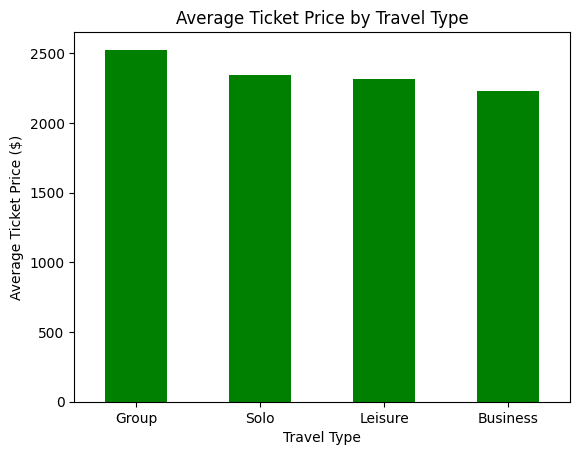

In [ ]:
avg_price = df.groupby("Travel_Type")["Ticket_Price"].mean().sort_values(ascending=False)
avg_price.plot(kind="bar", color="Green")
plt.title("Average Ticket Price by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Average Ticket Price ($)")
plt.xticks(rotation=0)
plt.show()

* The chart compares the average ticket price across different travel types.

* Some travel types have noticeably higher average ticket prices than others, indicating differences in travel costs and customer spending patterns.

* Features used: **Travel_Type** and **Ticket_Price**, with the average ticket price calculated for each travel type.

* The chart helps identify the most expensive and least expensive travel types, which can support pricing, marketing, and customer segmentation decisions.


## 2. Cancellation Rate by Country

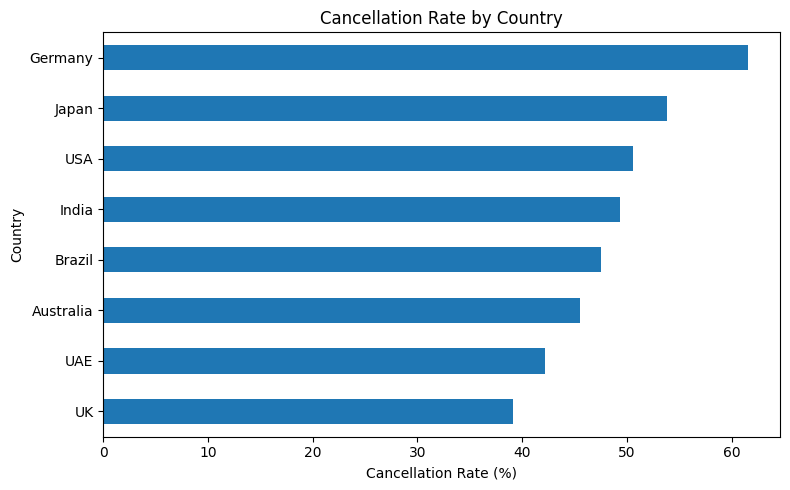

In [ ]:
# Creating cancellation flag
df["Canceled"] = df["Status"].apply(lambda x: 1 if x == "Canceled" else 0)

# Calculating cancellation rate by country
cancel_rate = df.groupby("Country")["Canceled"].mean() * 100
cancel_rate = cancel_rate.sort_values()

plt.figure(figsize=(8, 5))
cancel_rate.plot(kind="barh")

plt.title("Cancellation Rate by Country")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

* The chart compares the cancellation rates of bookings across different countries using a horizontal bar chart.
* Germany has the highest cancellation rate, while the UK has the lowest, indicating differences in booking behavior across countries.
* Features used: Country, Booking Status, and Cancellation Rate (%) calculated from canceled bookings divided by total bookings.
* The chart highlights which countries contribute most to booking cancellations and where efforts to reduce cancellations should be focused

### 3. Distribution of Bookings by Stay Duration

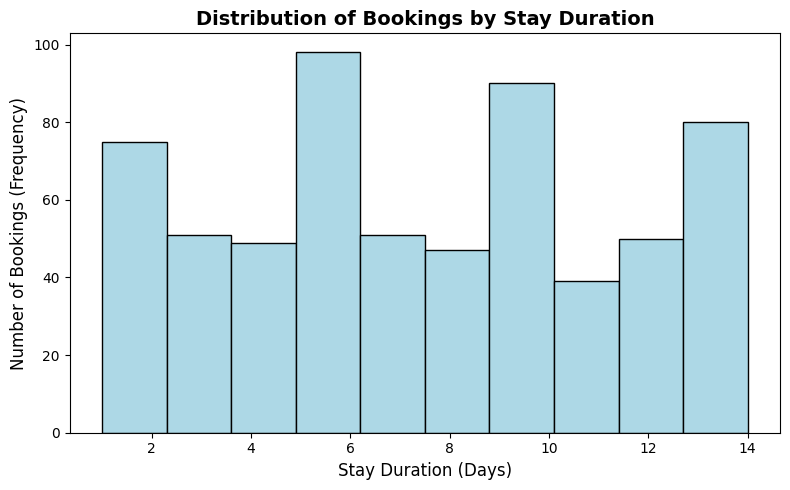

In [ ]:
plt.figure(figsize=(8, 5))
df["Stay_Duration"].plot(kind="hist", bins=10, color="lightblue", edgecolor="black")
plt.title("Distribution of Bookings by Stay Duration", fontsize=14, fontweight="bold")
plt.xlabel("Stay Duration (Days)", fontsize=12)
plt.ylabel("Number of Bookings (Frequency)", fontsize=12)
plt.tight_layout()
plt.show()

* The histogram shows how bookings are distributed across different stay durations.

* Most bookings are concentrated within certain stay durations, while very short or very long stays occur less frequently.

* Features used: **Stay_Duration** and **Frequency (Number of Bookings)**, grouped into 10 bins to visualize the distribution.

* The chart helps identify the most common length of stay among travelers, which can support package planning, pricing strategies, and resource allocation.


## 4. Meal Plan by Travel Type

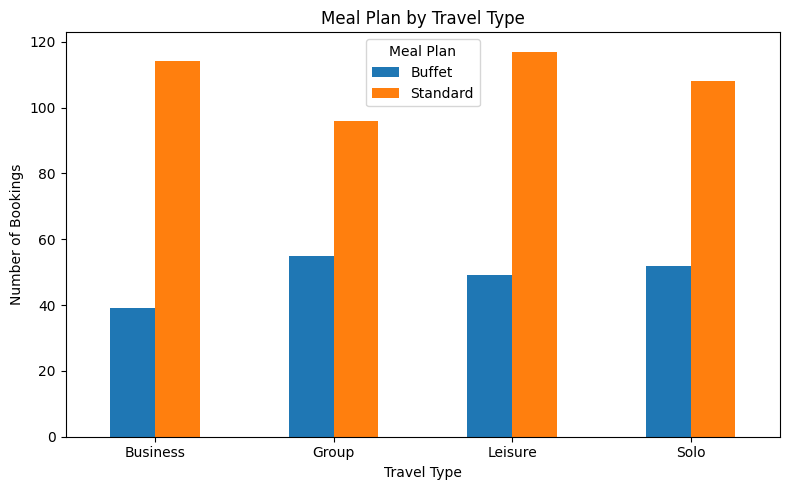

In [ ]:
# Counting bookings by Travel Type and Meal Plan
meal_travel = pd.crosstab(df["Travel_Type"], df["Meal_Plan"])
meal_travel.plot(kind="bar", figsize=(8, 5))

plt.title("Meal Plan by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.legend(title="Meal Plan")
plt.tight_layout()
plt.show()

* The chart compares the number of bookings for different meal plans across each travel type.

* It shows which meal plans are most preferred within each travel type and highlights differences in customer preferences.

* Features used: **Travel_Type**, **Meal_Plan**, and **Booking Count** obtained using a cross-tabulation of the two categories.

* The chart helps identify the most popular meal plan for each travel type, which can support package customization, marketing strategies, and service planning.


## 5. Revenue Share by Country

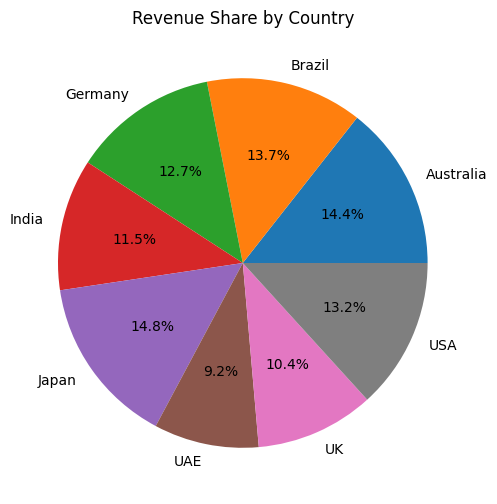

In [ ]:
revenue_share = df.groupby("Country")["Ticket_Price"].sum()
plt.figure(figsize=(6,6))
plt.pie(
    revenue_share,
    labels=revenue_share.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Share by Country")
plt.show()

* The pie chart shows the percentage contribution of each country to the total revenue generated from ticket sales.

* Some countries contribute a larger share of revenue than others, indicating stronger customer demand or higher spending levels from those markets.

* Features used: **Country** and **Ticket_Price**, with total revenue calculated by summing ticket prices for each country.

* The chart helps identify the most valuable countries in terms of revenue generation and supports decisions related to marketing, customer targeting, and business expansion.


## 6. Average Review Score by Travel Type and Transport Mode

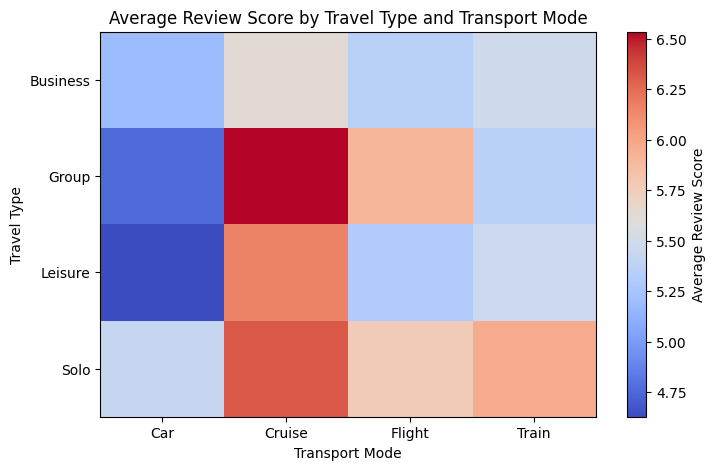

In [ ]:
heatmap_data = df.pivot_table(
    values="Review_Score",
    index="Travel_Type",
    columns="Transport_Mode",
    aggfunc="mean"
)
plt.figure(figsize=(8,5))
plt.imshow(heatmap_data, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Average Review Score")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.title("Average Review Score by Travel Type and Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Travel Type")

plt.show()

* The heatmap compares the average review scores for different combinations of travel types and transport modes.

* Higher values (darker cells) indicate combinations that receive better customer reviews, while lower values indicate comparatively lower satisfaction.

* Features used: **Travel_Type**, **Transport_Mode**, and **Review_Score**, with the average review score calculated for each combination.

* The heatmap helps identify the travel type and transport mode combinations that provide the best customer experience and can guide future service and package improvements.


# **Downloading the cleaned dataset for visualization in PowerBI**

In [ ]:
dataset = df.copy()

In [ ]:
dataset.to_csv('Cleaned_tourism_dataset.csv', index=False)

In [ ]:
dataset

,Booking_ID,Country,Age,Gender,Travel_Type,Ticket_Price,Stay_Duration,Hotel_Rating,Transport_Mode,Insurance,Meal_Plan,Review_Score,Baggage_KG,Status,Canceled
0,BK-5000,Brazil,26,Male,Leisure,928.0,2.0,4,Car,Yes,Standard,4,27,Confirmed,0
1,BK-5001,Japan,29,Male,Group,2243.0,5.0,5,Train,No,Buffet,9,37,Canceled,1
2,BK-5002,UAE,70,Female,Business,4397.0,13.0,1,Flight,Yes,Standard,5,37,Confirmed,0
3,BK-5003,Brazil,18,Female,Business,3696.0,14.0,3,Train,Yes,Standard,8,38,Confirmed,0
4,BK-5004,India,75,Female,Business,978.0,5.0,4,Car,No,Buffet,9,25,Confirmed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,BK-5625,UK,68,Female,Business,1767.0,3.0,4,Train,No,Standard,3,15,Canceled,1
626,BK-5626,UAE,32,Male,Solo,238.0,10.0,1,Flight,Yes,Buffet,4,33,Confirmed,0
627,BK-5627,Germany,42,Female,Solo,2744.0,3.0,4,Flight,Yes,Standard,2,27,Canceled,1
628,BK-5628,Brazil,72,Female,Business,1456.0,9.0,2,Flight,No,Standard,4,32,Confirmed,0


# **Documentation, Insights and Presentation**


# **Dashboard**

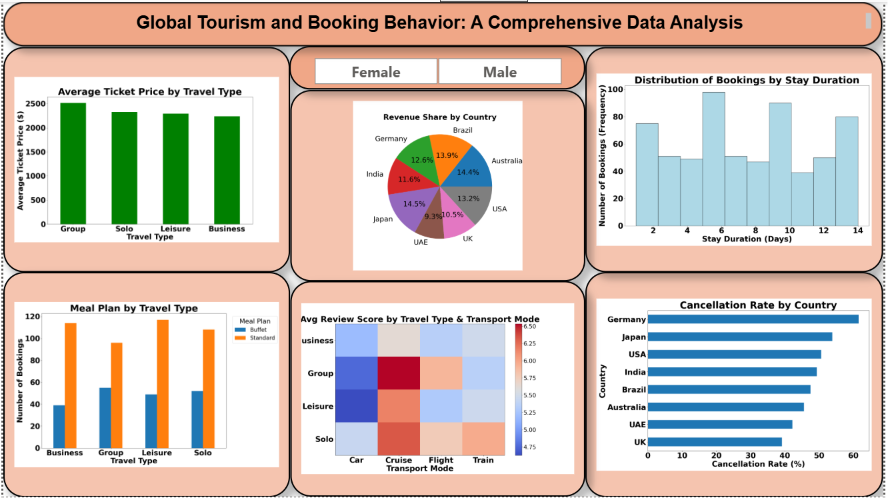

# **Summary of findings**
The results in the dashboard show that ticket prices are relatively similar across travel types, revenue is distributed fairly evenly among countries, cancellation rates are high in several markets, and customer satisfaction varies significantly depending on the combination of travel type and transport mode.

The biggest business opportunity lies in improving customer experience for lower-rated transport options while reducing cancellations in high-risk countries.

# **Insights and Recommendations**

* Customers are spending similar amounts regardless of travel type, suggesting that pricing is fairly consistent across segments.

* Rather than increasing prices, the company may achieve better results by increasing booking volume and customer retention.

* Revenue is not dependent on a single country.

* This diversification reduces business risk because revenue is spread across multiple markets.

* A significant proportion of bookings are not being completed.

* Cancellation management should become a priority.

* Deposit requirements, Reminder notifications, Loyalty incentives, and Flexible rescheduling options can be considered to reduce the cancellation rate.

* Standard meal plans dominate and Buffet plans are much less frequently selected.

* Customers generally prefer simpler and more economical meal options.

* Resources should focus on optimizing standard meal offerings rather than expanding buffet services.

* Group + Cruise & Leisure + Cruise have the Highest ratings and Group + Car & Leisure + Car have Lower ratings.

* Transport choice has a stronger effect on satisfaction than travel type. Cruise experiences appear to provide the best customer experience.

* Promote cruise packages more aggressively and investigate why car-based trips receive lower ratings.

* The histogram is fairly spread out rather than concentrated around a single duration.

* Bookings Peak around 5–6 days, 9–10 days and 14 days

* Customers do not follow one standard vacation length. Offer multiple package durations instead of focusing only on short or long trips.

# **Stage4_doc:**

https://drive.google.com/drive/folders/1jlOHHzE8BkKWV2vmADwGIurdei_THWzw?usp=sharing

# **Conclusion**

The tourism business is performing consistently across markets, but future growth depends on three priorities:

1. Reducing cancellations
2. Expanding high-rated travel experiences (especially cruises)
3. Improving lower-rated services while tailoring packages to customer preferences